# Notebook 14: Statistics in Machine Learning

**Sprint 2: Statistics & Mathematics for AI/ML Engineers**

---

## How is Statistics Used in Machine Learning?

Machine Learning is statistics applied at scale. Almost every step of an ML project uses a statistical idea that we learned in Notebooks 1 to 13.

**Analogy:** Building a house. Statistics is the foundation (understanding the land), and ML models are the building on top. A weak foundation (dirty data, wrong assumptions) makes even a fancy building fall.

| ML step | Statistical idea behind it | Notebook |
|---|---|---|
| Data cleaning | Sampling, data types, duplicates | 1, 7 |
| Missing values | Mean, median, mode | 2 |
| Outlier detection | IQR, Z-score | 9 |
| Feature engineering | Distributions, skewness, correlation | 4, 8 |
| Scaling / normalization | Mean, standard deviation, Z-score, range | 2, 3 |
| Model evaluation | Probability, hypothesis testing, confidence intervals | 5, 10 |
| Linear Regression | Variance, covariance, normal errors, t-test | 3, 8, 11 |
| Logistic Regression | Bernoulli distribution, odds, likelihood | 6 |
| Naive Bayes | Bayes' Theorem, independence | 5 |
| Clustering | Distance, variance | 3 |
| PCA | Variance, covariance matrix | 3, 8 |
| Recommendation systems | Correlation, similarity | 8 |

**Topics covered:** Data Cleaning, Missing Value Handling, Outlier Detection, Feature Engineering, Feature Scaling, Data Normalization, Model Evaluation, Linear Regression, Logistic Regression, Naive Bayes, Clustering, PCA, Recommendation Systems.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.datasets import make_classification, make_blobs, load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (StandardScaler, MinMaxScaler, RobustScaler,
                                   Normalizer, PowerTransformer)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, log_loss, silhouette_score,
                             mean_absolute_error, mean_squared_error, r2_score)

sns.set_theme(style="whitegrid")
np.random.seed(42)

## 1. Data Cleaning

**Definition:** Data cleaning is fixing or removing wrong, duplicate, inconsistent or incomplete data before modelling. It is often 60 to 80% of the work in a real ML project.

**Common problems and statistical checks:**

| Problem | Example | Check / Fix |
|---|---|---|
| Duplicates | Same customer twice | `duplicated()`, `drop_duplicates()` |
| Wrong data type | Age stored as text | `pd.to_numeric()` |
| Inconsistent text | "chennai", "CHENNAI", "Chennai " | strip, lower / title case |
| Impossible values | Age = -5 | Range check, set to NaN |
| Missing values | Salary blank | Imputation (next section) |
| Outliers | Salary = 10 lakh crore | IQR / Z-score (Notebook 9) |

**Numerical Example:** 1,000 rows with 100 duplicates. The mean of a column can change a lot, because duplicated customers are counted twice, so the statistics become biased.

**Business Example:** A bank merges customer lists from two branches. Without removing duplicates, the same customer is counted twice, and the "number of customers" and "average balance" reports are wrong.

**AI/ML Example:** Duplicates between the train and test sets cause **data leakage**: the model has already seen the test rows, so the accuracy looks better than it really is. "Garbage in, garbage out."

In [3]:
raw = pd.DataFrame({
    "name":   ["Raj", "anu ", " Kumar", "Raj", "Divya", "Meena"],
    "age":    ["25", "32", "29", "25", "-5", "41"],        # stored as text, one impossible value
    "city":   ["chennai", "MADURAI", "Trichy", "chennai", "Chennai", "madurai"],
    "salary": [50000, 62000, np.nan, 50000, 48000, 1_000_000],
})
print("RAW DATA")
print(raw)
print("\nData types:\n", raw.dtypes)
print("Duplicate rows:", raw.duplicated().sum())

clean = raw.copy()
clean["name"] = clean["name"].str.strip().str.title()          # fix spaces and case
clean["city"] = clean["city"].str.strip().str.title()
clean["age"] = pd.to_numeric(clean["age"])                      # text to number
clean.loc[(clean["age"] <= 0) | (clean["age"] > 100), "age"] = np.nan   # impossible ages
clean = clean.drop_duplicates()                                 # remove repeated rows

print("\nCLEAN DATA")
print(clean)
print("\nMissing values per column:\n", clean.isna().sum())
print("\nRows before:", len(raw), "| Rows after:", len(clean))

RAW DATA
     name age     city     salary
0     Raj  25  chennai    50000.0
1    anu   32  MADURAI    62000.0
2   Kumar  29   Trichy        NaN
3     Raj  25  chennai    50000.0
4   Divya  -5  Chennai    48000.0
5   Meena  41  madurai  1000000.0

Data types:
 name          str
age           str
city          str
salary    float64
dtype: object
Duplicate rows: 1

CLEAN DATA
    name   age     city     salary
0    Raj  25.0  Chennai    50000.0
1    Anu  32.0  Madurai    62000.0
2  Kumar  29.0   Trichy        NaN
4  Divya   NaN  Chennai    48000.0
5  Meena  41.0  Madurai  1000000.0

Missing values per column:
 name      0
age       1
city      0
salary    1
dtype: int64

Rows before: 6 | Rows after: 5


**Explanation:** We start with a messy table: text ages, mixed upper and lower case cities, a repeated row, a negative age and an extreme salary. We fix the text, convert the age to numbers, mark impossible ages as missing (NaN), and drop duplicates. Note that "Chennai" and "chennai" were counted as different cities before cleaning.

**Interpretation:** After cleaning there are only 3 distinct cities written consistently, the duplicate Raj row is gone, and the impossible age became NaN. The data still has missing values (age, salary) and a suspicious salary of 10 lakh, which we handle in the next sections. **Cleaning does not finish the job, it prepares the data for the next statistical steps.**

## 2. Missing Value Handling

**Definition:** Missing values are empty cells in the data. We either **delete** them or **fill (impute)** them using a statistic.

**Types of missingness:**
- **MCAR** (Missing Completely At Random): no pattern, for example a sensor randomly fails.
- **MAR** (Missing At Random): depends on other columns, for example younger people skip the income question.
- **MNAR** (Missing Not At Random): depends on the missing value itself, for example high earners hide their income.

**Which statistic to use (Notebook 2):**

| Column type | Method | Use when |
|---|---|---|
| Numeric, symmetric | **Mean** | No outliers |
| Numeric, skewed / outliers | **Median** | Income, price |
| Categorical | **Mode** | City, gender |
| Any | Model-based (KNN imputer, regression) | Features are related |

**Formula:** Mean imputation replaces every missing x with

$$\hat{x} = \bar{x}_{observed}$$

**Numerical Example:** Ages = 20, 30, NaN, 40. The mean of the observed values = 30, so the NaN becomes 30.

**Side effect:** Filling with one constant value **reduces the variance** (many points sit exactly at the mean), which makes the data look less spread than it really is.

**Business Example:** A survey has 20% of income answers blank. Using the median income fills the gaps without being pulled by a few millionaires.

**AI/ML Example:** Most ML models cannot accept NaN. `SimpleImputer` fits the median on the **training data only** and applies it to the test data (to avoid leakage). A **missing indicator** column ("was it missing?") can itself be a useful feature.

Missing percentage:
 income    20.4
city      11.0
dtype: float64

                       Mean   Median      Std
True (full data)   40420.0  36428.0  21126.0
Drop missing rows  40818.0  36781.0  21238.0
Mean imputation    40818.0  40818.0  18945.0
Median imputation  39995.0  36781.0  19015.0

City filled with mode: Chennai

Median learned from train data: 37294
Output columns (income, missing_indicator): 2


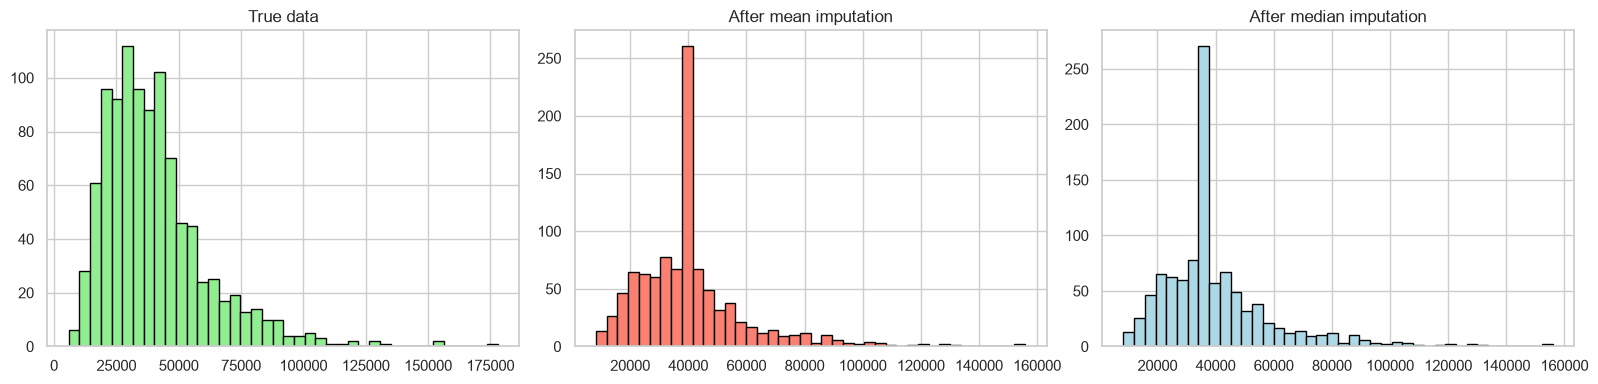

In [4]:
rng = np.random.default_rng(42)
n = 1000
full = pd.DataFrame({
    "income": rng.lognormal(10.5, 0.5, n),                    # right-skewed
    "city": rng.choice(["Chennai", "Madurai", "Trichy"], n, p=[0.5, 0.3, 0.2]),
})
true_mean, true_median, true_std = full["income"].mean(), full["income"].median(), full["income"].std()

# Make 20% of income and 10% of city missing
df_miss = full.copy()
df_miss.loc[rng.random(n) < 0.20, "income"] = np.nan
df_miss.loc[rng.random(n) < 0.10, "city"] = np.nan
print("Missing percentage:\n", (df_miss.isna().mean() * 100).round(1))

# Compare imputation methods for income
mean_imp = df_miss["income"].fillna(df_miss["income"].mean())
median_imp = df_miss["income"].fillna(df_miss["income"].median())

summary = pd.DataFrame({
    "Mean": [true_mean, df_miss["income"].mean(), mean_imp.mean(), median_imp.mean()],
    "Median": [true_median, df_miss["income"].median(), mean_imp.median(), median_imp.median()],
    "Std": [true_std, df_miss["income"].std(), mean_imp.std(), median_imp.std()],
}, index=["True (full data)", "Drop missing rows", "Mean imputation", "Median imputation"]).round(0)
print("\n", summary)

# Categorical: mode imputation
city_mode = df_miss["city"].mode()[0]
df_miss["city"] = df_miss["city"].fillna(city_mode)
print("\nCity filled with mode:", city_mode)

# Proper way in ML: fit on TRAIN only, apply to TEST (no leakage)
X_tr, X_te = train_test_split(df_miss[["income"]], test_size=0.3, random_state=42)
imp = SimpleImputer(strategy="median", add_indicator=True).fit(X_tr)
print("\nMedian learned from train data:", round(imp.statistics_[0]))
print("Output columns (income, missing_indicator):", imp.transform(X_te).shape[1])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(full["income"], bins=40, color="lightgreen", edgecolor="black"); axes[0].set_title("True data")
axes[1].hist(mean_imp, bins=40, color="salmon", edgecolor="black"); axes[1].set_title("After mean imputation")
axes[2].hist(median_imp, bins=40, color="lightblue", edgecolor="black"); axes[2].set_title("After median imputation")
plt.tight_layout()
plt.show()

**Explanation:** We create income data (right-skewed), delete 20% of it at random, and compare mean and median imputation with the true statistics. Categorical gaps are filled with the mode. Finally, `SimpleImputer` is fitted on the training part only. The histograms show the effect of imputation on the shape.

**Interpretation:** The skewed data has mean > median. Both imputations create a **tall spike** at the filled value, and the standard deviation becomes smaller than the true one, so the spread is underestimated. Median imputation keeps the typical value closer for skewed income. The better the method preserves the distribution, the better it is for the model. When many values are missing (above about 30 to 40%), model-based imputation (KNN, regression) or collecting more data is safer.

## 3. Outlier Detection

**Definition:** Finding values that are very different from the rest, using IQR, Z-score and plots (full details in Notebook 9).

**Formulas:**

$$Lower = Q_1 - 1.5 \times IQR, \quad Upper = Q_3 + 1.5 \times IQR, \quad Z = \frac{x - \mu}{\sigma}$$

**Numerical Example:** Q1 = 40000, Q3 = 70000, so IQR = 30000, upper fence = 70000 + 45000 = **115000**. A salary of 5,00,000 is an outlier.

**Business Example:** A payment system flags a transaction of Rs. 5 lakh for a customer who normally spends Rs. 2,000.

**AI/ML Example:**
- **Cleaning:** outliers distort the mean, the standard deviation and the fitted line of Linear Regression.
- **Anomaly detection:** in fraud detection, the outliers **are** the target we want to find.
- **Scaling:** outliers squeeze all the other values after Min-Max scaling, so we use `RobustScaler` or capping.

Outliers found by IQR: 3
Z-score > 3 count    : 3

True slope = 3
Slope with outliers   : 3.64
Slope without outliers: 3.09


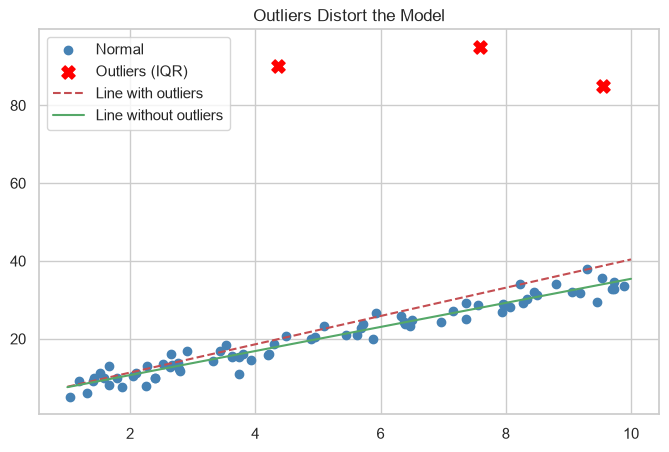

In [5]:
np.random.seed(42)
x = np.random.uniform(1, 10, 80)
y = 3 * x + 5 + np.random.normal(0, 2, 80)
y_out = y.copy()
y_out[:3] = [90, 85, 95]            # three extreme values

def iqr_flags(a, k=1.5):
    q1, q3 = np.percentile(a, [25, 75])
    iqr = q3 - q1
    return (a < q1 - k * iqr) | (a > q3 + k * iqr)

flags = iqr_flags(y_out)
print("Outliers found by IQR:", flags.sum())
print("Z-score > 3 count    :", (np.abs(stats.zscore(y_out)) > 3).sum())

# Effect on a regression line
slope_dirty = LinearRegression().fit(x.reshape(-1, 1), y_out).coef_[0]
slope_clean = LinearRegression().fit(x[~flags].reshape(-1, 1), y_out[~flags]).coef_[0]
print("\nTrue slope = 3")
print("Slope with outliers   :", round(slope_dirty, 2))
print("Slope without outliers:", round(slope_clean, 2))

plt.figure(figsize=(8, 5))
plt.scatter(x[~flags], y_out[~flags], color="steelblue", label="Normal")
plt.scatter(x[flags], y_out[flags], color="red", s=90, marker="X", label="Outliers (IQR)")
xs = np.linspace(1, 10, 50)
plt.plot(xs, slope_dirty * xs + LinearRegression().fit(x.reshape(-1, 1), y_out).intercept_, "r--", label="Line with outliers")
plt.plot(xs, slope_clean * xs + LinearRegression().fit(x[~flags].reshape(-1, 1), y_out[~flags]).intercept_, "g-", label="Line without outliers")
plt.legend(); plt.title("Outliers Distort the Model"); plt.show()

**Explanation:** We add three extreme y values to clean linear data and detect them with the IQR rule (and count Z-scores for comparison). Then we fit Linear Regression with and without them.

**Interpretation:** The slope with outliers is pulled away from the true value 3, while the slope after removing them is close to 3. **A few bad points can change what the model learns.** Before removing, we must ask whether they are errors or real events (Notebook 9).

## 4. Feature Engineering

**Definition:** Creating new, more useful features from the existing ones using domain knowledge and statistics, so the model can see patterns more easily.

**Common techniques:**

| Technique | Example | Statistical reason |
|---|---|---|
| **Log / sqrt transform** | log(income) | Reduces right skew (Notebook 4) |
| **Ratios** | income per family member | Combines two variables into a meaningful one |
| **Binning** | age into groups | Captures non-linear effects, reduces noise |
| **Interaction** | age x income | Effect of one feature depends on another |
| **Date parts** | month, weekday, is_weekend | Captures seasonality |
| **Aggregation** | average spend per customer | Summary statistics (mean, count) |
| **Encoding** | one-hot encode a city | Converts categories into numbers |

**Numerical Example:** Income = 1,00,000 and 4 members gives income per member = **25,000**, which describes the family's real purchasing power better than total income.

**Business Example:** A telecom company creates "average monthly data usage in the last 3 months" and "number of complaints in the last 30 days" to predict churn.

**AI/ML Example:** Good features often matter more than a complex algorithm. Skewed features are log-transformed, dates are split into parts, and text is converted into numbers.

In [6]:
np.random.seed(42)
n = 500
fe = pd.DataFrame({
    "income": np.random.lognormal(10.5, 0.6, n),
    "family_size": np.random.randint(1, 7, n),
    "age": np.random.randint(18, 70, n),
    "order_date": pd.to_datetime("2025-01-01") + pd.to_timedelta(np.random.randint(0, 365, n), unit="D"),
})
fe["spend"] = 0.02 * fe["income"] / np.sqrt(fe["family_size"]) + np.random.normal(0, 100, n)

# New features
fe["log_income"] = np.log(fe["income"])                                   # reduce skew
fe["income_per_member"] = fe["income"] / fe["family_size"]                # ratio
fe["age_group"] = pd.cut(fe["age"], bins=[17, 30, 45, 60, 100],
                         labels=["18-30", "31-45", "46-60", "60+"])      # binning
fe["month"] = fe["order_date"].dt.month                                   # date part
fe["is_weekend"] = (fe["order_date"].dt.dayofweek >= 5).astype(int)
fe["age_x_log_income"] = fe["age"] * fe["log_income"]                     # interaction

print(fe[["income", "log_income", "income_per_member", "age_group", "month", "is_weekend"]].head())
print("\nSkewness income     :", round(stats.skew(fe["income"]), 2))
print("Skewness log_income :", round(stats.skew(fe["log_income"]), 2))

print("\nCorrelation with spend:")
print(fe[["income", "log_income", "income_per_member", "family_size", "age"]].corrwith(fe["spend"]).round(3))
print("\nAverage spend by age group:\n", fe.groupby("age_group", observed=True)["spend"].mean().round(0))

pd.get_dummies(fe["age_group"], prefix="age", drop_first=True).head(3)   # one-hot encoding

         income  log_income  income_per_member age_group  month  is_weekend
0  48924.251431   10.798028       24462.125715     46-60      6           1
1  33424.398935   10.417041       16712.199467     46-60     12           0
2  53562.963185   10.888613       17854.321062     31-45      3           0
3  90564.529961   11.413818       30188.176654     46-60      6           0
4  31555.651338   10.359508        6311.130268     46-60      5           0

Skewness income     : 3.6
Skewness log_income : 0.18

Correlation with spend:
income               0.830
log_income           0.756
income_per_member    0.894
family_size         -0.390
age                 -0.009
dtype: float64

Average spend by age group:
 age_group
18-30    565.0
31-45    488.0
46-60    554.0
60+      489.0
Name: spend, dtype: float64


,age_31-45,age_46-60,age_60+
0,False,True,False
1,False,True,False
2,True,False,False


**Explanation:** We start with raw columns and create six new features: a log transform, a ratio (income per member), age bins, month and weekend flag from the date, and an interaction. We compare skewness, and check which features correlate best with spend. `get_dummies` shows one-hot encoding.

**Interpretation:** The skewness of income falls close to 0 after the log transform. In this data, spend is built from income divided by family size, so the engineered feature `income_per_member` should show a stronger correlation with spend than raw `income` or `family_size`. This is the main message: **a feature made with domain knowledge can reveal a relationship that the raw columns hide.** (Read your own correlation output to confirm.)

## 5. Feature Scaling

**Definition:** Bringing features onto a similar scale so no feature dominates only because of its units (income in lakhs vs age in years).

**Methods:**

| Method | Formula | Result | Use when |
|---|---|---|---|
| **Standardization** (Z-score) | (x - mean) / std | Mean 0, std 1 | Most cases, roughly normal data |
| **Min-Max scaling** | (x - min) / (max - min) | Range 0 to 1 | Bounded range needed (neural nets, images) |
| **Robust scaling** | (x - median) / IQR | Median 0 | Data with outliers |

**Formulas:**

$$z = \frac{x - \mu}{\sigma} \qquad x' = \frac{x - x_{min}}{x_{max} - x_{min}} \qquad x' = \frac{x - \text{median}}{IQR}$$

**Numerical Example:** Ages 20, 30, 40, 50, 60 (mean 40, std = 14.14).
Standardized: -1.41, -0.71, 0, 0.71, 1.41.
Min-Max: 0, 0.25, 0.5, 0.75, 1.

**Business Example:** Comparing a customer's score on different scales (credit score 300 to 900 and income in lakhs) in one segmentation.

**AI/ML Example:**
- **Needed (distance or gradient based):** KNN, K-Means, SVM, PCA, Logistic / Linear Regression with regularization, neural networks.
- **Not needed:** tree-based models (Decision Tree, Random Forest, XGBoost).
- **Rule:** fit the scaler on the **training data only**, then transform the test data.

Standardized: [-1.41 -0.71  0.    0.71  1.41]
Min-Max     : [0.   0.25 0.5  0.75 1.  ]

Middle 50% of the data after scaling (Q1 to Q3):
Original  Q1 =  27468.415 | Q3 =  47044.265
Standard  Q1 =     -0.147 | Q3 =     -0.008
Min-Max   Q1 =      0.007 | Q3 =      0.015
Robust    Q1 =     -0.465 | Q3 =      0.535


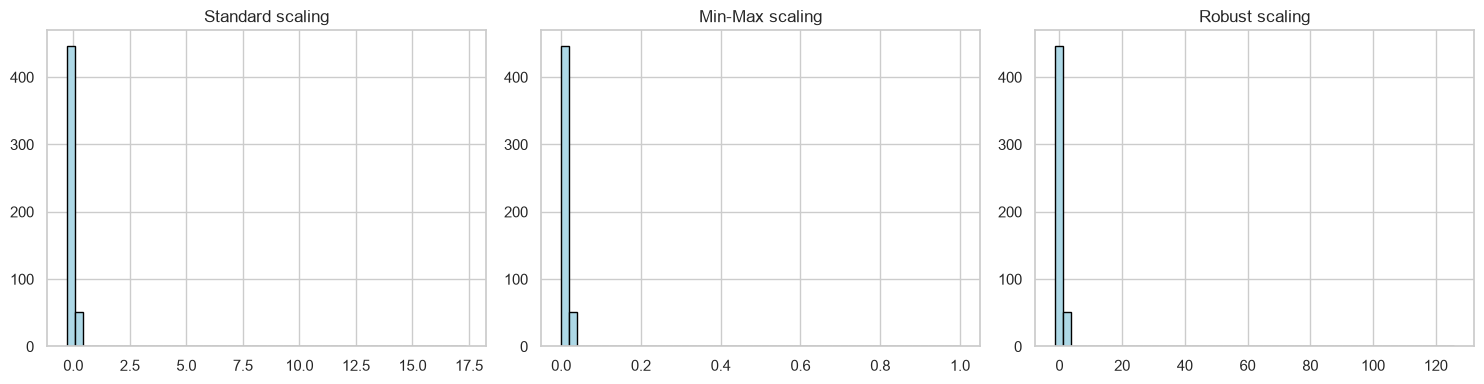


KNN accuracy WITHOUT scaling: 0.505
KNN accuracy WITH scaling   : 0.732


In [7]:
np.random.seed(42)
ages = np.array([20, 30, 40, 50, 60]).reshape(-1, 1)
print("Standardized:", StandardScaler().fit_transform(ages).ravel().round(2))
print("Min-Max     :", MinMaxScaler().fit_transform(ages).ravel().round(2))

# Skewed income with outliers
income = np.append(np.random.lognormal(10.5, 0.4, 500), [2_000_000, 2_500_000]).reshape(-1, 1)
scaled = {
    "Original": income.ravel(),
    "Standard": StandardScaler().fit_transform(income).ravel(),
    "Min-Max": MinMaxScaler().fit_transform(income).ravel(),
    "Robust": RobustScaler().fit_transform(income).ravel(),
}
print("\nMiddle 50% of the data after scaling (Q1 to Q3):")
for name, v in scaled.items():
    print(f"{name:9s} Q1 = {np.percentile(v, 25):10.3f} | Q3 = {np.percentile(v, 75):10.3f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, key in zip(axes, ["Standard", "Min-Max", "Robust"]):
    ax.hist(scaled[key], bins=50, color="lightblue", edgecolor="black")
    ax.set_title(f"{key} scaling")
plt.tight_layout(); plt.show()

# Why scaling matters: KNN with an informative small-scale feature and a noisy huge-scale feature
rng = np.random.default_rng(42)
y_cls = rng.integers(0, 2, 600)
x1 = y_cls * 1.5 + rng.normal(0, 1, 600)          # informative, scale about 1
x2 = rng.normal(0, 1000, 600)                     # pure noise, scale about 1000
X = np.c_[x1, x2]

acc_raw = cross_val_score(KNeighborsClassifier(), X, y_cls, cv=5).mean()
acc_scaled = cross_val_score(make_pipeline(StandardScaler(), KNeighborsClassifier()), X, y_cls, cv=5).mean()
print("\nKNN accuracy WITHOUT scaling:", round(acc_raw, 3))
print("KNN accuracy WITH scaling   :", round(acc_scaled, 3))

**Explanation:** First we apply the formulas to 5 ages and match our hand calculation. Then we scale skewed income that has two extreme values, and look at where the middle 50% of the data lands. Finally, a KNN experiment: one useful feature with a small scale and one useless feature with a huge scale. The scaler is placed inside a `pipeline`, so it is fitted only on the training folds of cross-validation.

**Interpretation:**
- With extreme outliers, **Min-Max** squeezes almost all values into a tiny range near 0, so the data loses its resolution. **Robust** scaling keeps the middle 50% spread out, because it uses the median and IQR.
- Without scaling, KNN's distance is almost completely decided by the noisy feature (scale 1000), so the accuracy stays close to random (about 50%). After scaling, the useful feature counts, and the accuracy rises clearly. **Scaling can decide whether a distance-based model works at all.**

## 6. Data Normalization

**Definition:** "Normalization" is used in two ways, so we must be clear:
1. **Scaling to a range** (Min-Max, 0 to 1), or scaling each **row** (sample) to length 1 (L2 normalization).
2. **Making the distribution more normal (bell-shaped)** using transformations such as log, Box-Cox or Yeo-Johnson (a *normalizing transformation*).

**Formulas:**

Row-wise L2 normalization:

$$x' = \frac{x}{\lVert x \rVert_2} = \frac{x}{\sqrt{x_1^2 + x_2^2 + \dots + x_n^2}}$$

Log transform: x' = log(x)

**Standardization vs Normalization:**

| | Standardization | Normalization (Min-Max) | Normalizing transform (log, Yeo-Johnson) |
|---|---|---|---|
| Changes | Center and spread | Range | **Shape** of the distribution |
| Fixes skew? | No | No | **Yes** |
| Result | Mean 0, std 1 | 0 to 1 | More bell-shaped |

**Numerical Example (L2):** Vector (3, 4) has length sqrt(9 + 16) = 5, so the normalized vector is (0.6, 0.8), and its length is 1.

**Business Example:** Comparing documents of different lengths: a long article has bigger word counts than a short one, so each document's counts are normalized.

**AI/ML Example:** L2 normalization before cosine similarity or text models, Min-Max for images (pixels 0 to 255 become 0 to 1), and log / Yeo-Johnson transforms for skewed features before Linear Regression, which assumes roughly normal errors.

L2 normalized rows:
 [[0.6   0.8  ]
 [0.707 0.707]
 [0.6   0.8  ]]
Row lengths: [1. 1. 1.]

              Skewness  Shapiro p-value
Original       1.9437              0.0
Min-Max        1.9437              0.0
log1p         -0.1395              0.0
Yeo-Johnson   -0.0159              0.0


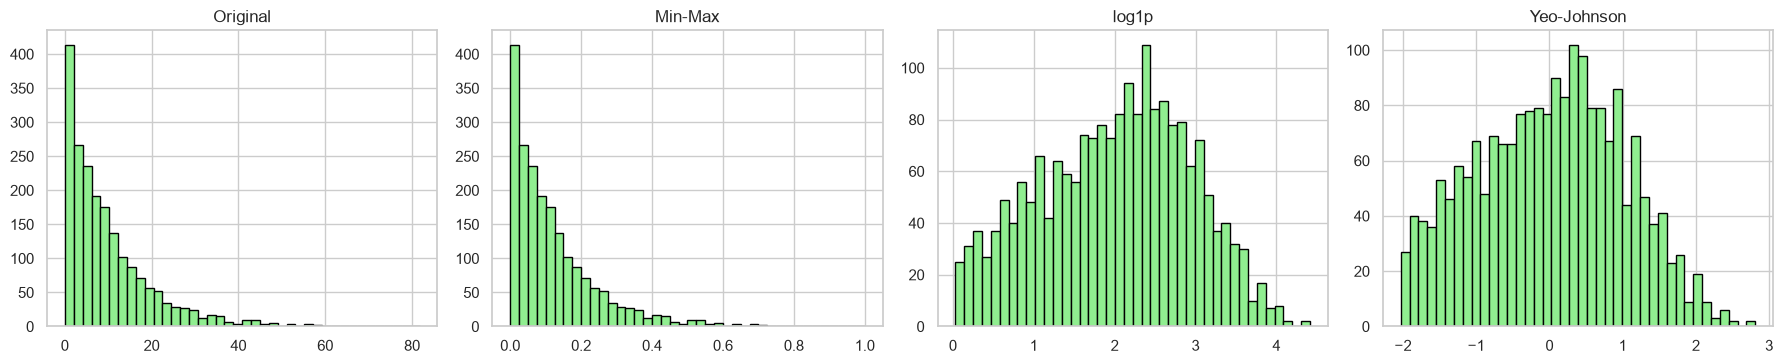

In [8]:
np.random.seed(42)
# 1. Row-wise L2 normalization
vec = np.array([[3, 4], [1, 1], [6, 8]])
norm_vec = Normalizer(norm="l2").fit_transform(vec)
print("L2 normalized rows:\n", norm_vec.round(3))
print("Row lengths:", np.linalg.norm(norm_vec, axis=1).round(2))

# 2. Min-Max does NOT change the shape (skewness)
skewed = np.random.exponential(scale=10, size=2000).reshape(-1, 1)
minmax = MinMaxScaler().fit_transform(skewed)

# 3. Normalizing transforms DO change the shape
logged = np.log1p(skewed)
yeo = PowerTransformer(method="yeo-johnson").fit_transform(skewed)

results = pd.DataFrame({
    "Skewness": [stats.skew(skewed.ravel()), stats.skew(minmax.ravel()),
                 stats.skew(logged.ravel()), stats.skew(yeo.ravel())],
    "Shapiro p-value": [stats.shapiro(a.ravel()[:500]).pvalue for a in [skewed, minmax, logged, yeo]],
}, index=["Original", "Min-Max", "log1p", "Yeo-Johnson"]).round(4)
print("\n", results)

fig, axes = plt.subplots(1, 4, figsize=(18, 3.8))
for ax, (title, arr) in zip(axes, [("Original", skewed), ("Min-Max", minmax), ("log1p", logged), ("Yeo-Johnson", yeo)]):
    ax.hist(arr.ravel(), bins=40, color="lightgreen", edgecolor="black")
    ax.set_title(title)
plt.tight_layout(); plt.show()

**Explanation:** First we L2-normalize three rows. Then we take a right-skewed variable and compare four versions: original, Min-Max, log1p and Yeo-Johnson. For each we print the skewness and the Shapiro-Wilk p-value (Notebook 11).

**Interpretation:** Every row of the L2-normalized data has length 1, and (3, 4) and (6, 8) became the same vector, because only the **direction** is kept. Min-Max changes only the range: the skewness stays the same, so the histogram has the same shape. `log1p` and Yeo-Johnson **reduce the skewness a lot** and make the shape much closer to a bell. So: **scaling changes the units, transformation changes the shape.**

## 7. Model Evaluation

**Definition:** Measuring how well a model works on **new, unseen data**, using statistical metrics, train/test splits and cross-validation.

**Regression metrics:**

$$MAE = \frac{1}{n}\sum |y_i - \hat{y}_i| \qquad RMSE = \sqrt{\frac{1}{n}\sum (y_i - \hat{y}_i)^2} \qquad R^2 = 1 - \frac{SS_{res}}{SS_{total}}$$

**Classification metrics (from the confusion matrix: TP, FP, FN, TN):**

$$Accuracy = \frac{TP + TN}{Total} \quad Precision = \frac{TP}{TP + FP} \quad Recall = \frac{TP}{TP + FN} \quad F1 = \frac{2PR}{P + R}$$

**Numerical Example (fraud model):** TP = 40, FP = 10, FN = 20, TN = 930.
Accuracy = 970 / 1000 = **97%**, Precision = 40 / 50 = **0.80**, Recall = 40 / 60 = **0.667**, F1 = **0.727**.

**Key statistical ideas:**
- **Accuracy can lie** on imbalanced data (a model that always says "not fraud" gets 94% if only 6% are fraud).
- **Precision vs Recall** is the Type I vs Type II error trade-off (Notebook 10): FP is a Type I error, FN is a Type II error.
- A single test score is a **sample estimate** with sampling error (Notebook 7), so we use **cross-validation** and report a **confidence interval**.
- **ROC-AUC:** the probability that the model ranks a random positive higher than a random negative (0.5 = random, 1 = perfect).

**Business Example:** A bank prefers high **recall** for fraud (catch most frauds), while an email spam filter prefers high **precision** (do not throw away real emails).

**AI/ML Example:** Comparing two models with cross-validation scores and a paired t-test (Notebook 11) to check whether the difference is real or only luck.

Always predict majority   Accuracy=0.893  Precision=0.000  Recall=0.000  F1=0.000
Logistic Regression       Accuracy=0.661  Precision=0.186  Recall=0.646  F1=0.289
ROC-AUC (Logistic): 0.741


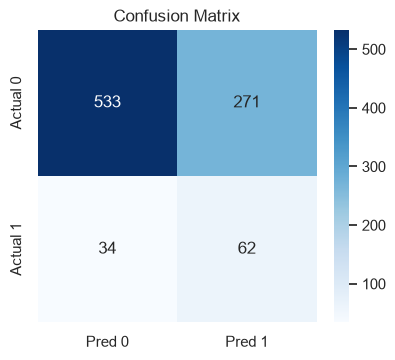


10-fold F1 scores: [0.242 0.271 0.343 0.317 0.257 0.269 0.26  0.286 0.278 0.212]
Mean F1 = 0.274 | 95% CI = (0.247, 0.300)

MAE : 12.0
RMSE: 12.65
R2  : 0.968


In [9]:
# Imbalanced data: 10% positives
X, y = make_classification(n_samples=3000, n_features=10, n_informative=4,
                           weights=[0.9, 0.1], flip_y=0.02, random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

dummy = DummyClassifier(strategy="most_frequent").fit(X_tr, y_tr)
model = make_pipeline(StandardScaler(), LogisticRegression(class_weight="balanced", max_iter=1000)).fit(X_tr, y_tr)

for name, m in [("Always predict majority", dummy), ("Logistic Regression", model)]:
    pred = m.predict(X_te)
    print(f"{name:25s} Accuracy={accuracy_score(y_te, pred):.3f}  Precision={precision_score(y_te, pred, zero_division=0):.3f}  "
          f"Recall={recall_score(y_te, pred):.3f}  F1={f1_score(y_te, pred):.3f}")
print("ROC-AUC (Logistic):", round(roc_auc_score(y_te, model.predict_proba(X_te)[:, 1]), 3))

# Confusion matrix
cm = confusion_matrix(y_te, model.predict(X_te))
plt.figure(figsize=(4.5, 3.8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred 0", "Pred 1"], yticklabels=["Actual 0", "Actual 1"])
plt.title("Confusion Matrix"); plt.show()

# Cross-validation with a confidence interval
scores = cross_val_score(model, X, y, cv=10, scoring="f1")
ci = stats.t.interval(0.95, df=len(scores) - 1, loc=scores.mean(), scale=stats.sem(scores))
print("\n10-fold F1 scores:", scores.round(3))
print(f"Mean F1 = {scores.mean():.3f} | 95% CI = ({ci[0]:.3f}, {ci[1]:.3f})")

# Regression metrics
y_true = np.array([100, 150, 200, 250, 300])
y_pred = np.array([110, 140, 210, 230, 310])
print("\nMAE :", mean_absolute_error(y_true, y_pred))
print("RMSE:", round(np.sqrt(mean_squared_error(y_true, y_pred)), 2))
print("R2  :", round(r2_score(y_true, y_pred), 3))

**Explanation:** We create data with only 10% positives and compare a "dumb" model (always predicts the majority class) with Logistic Regression. We print accuracy, precision, recall, F1 and ROC-AUC, draw the confusion matrix, run 10-fold cross-validation and build a 95% confidence interval for the F1 score. The last part calculates regression metrics.

**Interpretation:** The dumb model has about **90% accuracy** but **recall = 0**, because it never finds a single positive. Accuracy alone hides that. Logistic Regression has a lower accuracy but finds many more positives (higher recall and F1), so it is the more useful model. The 10 CV scores differ from fold to fold, so the confidence interval shows how much we can trust the F1 value. For regression, RMSE (about 12.2) is a bit larger than MAE (12) because RMSE punishes big errors more. **Always choose the metric that matches the business cost of errors.**

## 8. Linear Regression

**Definition:** Linear Regression fits a straight line (or plane) that predicts a numeric target from features, by choosing the coefficients that **minimize the sum of squared errors** (least squares).

**Formula:**

$$\hat{y} = \beta_0 + \beta_1 x_1 + \dots + \beta_k x_k \qquad \hat{\beta} = (X^T X)^{-1} X^T y$$

For one feature, the slope is directly a statistical quantity:

$$\beta_1 = \frac{Cov(X, Y)}{Var(X)} = r \cdot \frac{s_Y}{s_X}$$

**Numerical Example:** Hours studied x = 2, 4, 6, 8, 10 and marks y = 50, 60, 65, 80, 90 (Notebook 8): Cov = 50, Var(x) = 10, so slope = 50 / 10 = **5**. Intercept = 69 - 5 x 6 = **39**. So marks = 39 + 5 x hours.

**Statistics inside it:**
- **Covariance and variance** give the slope.
- **R-squared** = share of variance in y explained by the model.
- **t-test on each coefficient** (H0: coefficient = 0) tells whether a feature really matters (Notebook 10).
- **Assumptions:** linear relationship, independent errors, **normally distributed errors with constant variance**, and no strong multicollinearity (Notebook 12).

**Business Example:** Predicting sales from advertising spend: "each extra Rs. 1,000 of ads adds about Rs. 5,000 in sales."

**AI/ML Example:** The baseline model for any numeric prediction (house price, demand). Its coefficients are interpretable, which is valuable for explaining decisions.

Hand example: slope = 5.0 | intercept = 39.0

Manual regression table:
              coef  std err        t  p-value
intercept  3.4302   0.3406  10.0718      0.0
x          1.9080   0.0613  31.1269      0.0
R2: 0.9081

sklearn -> intercept: 3.4302 | slope: 1.908
Residual mean: 0.0 | Shapiro p-value of residuals: 0.298


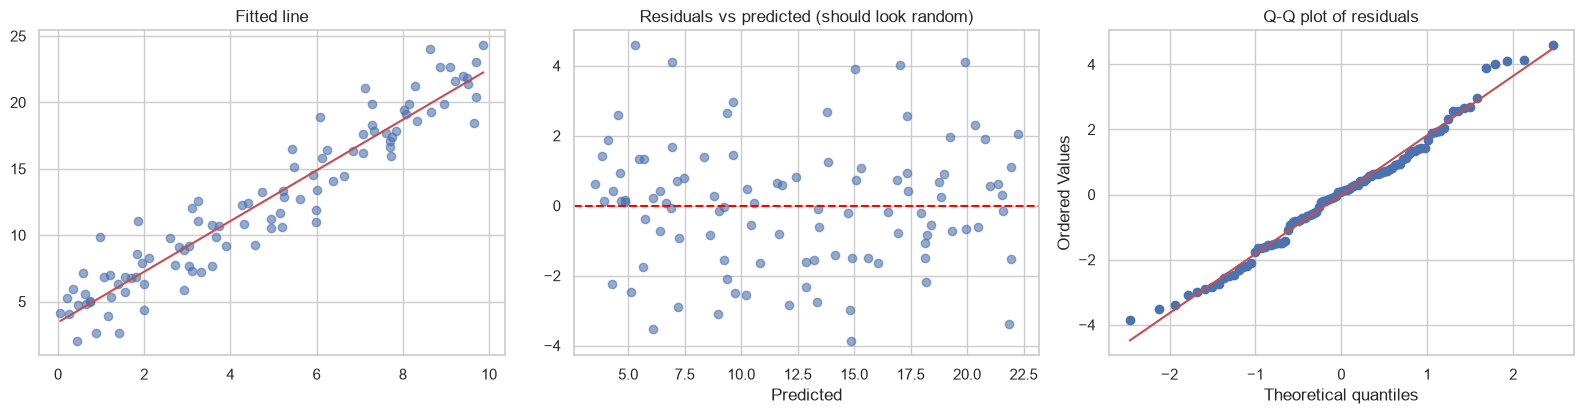

In [10]:
# Hand example from the markdown
hours = np.array([2, 4, 6, 8, 10]); marks = np.array([50, 60, 65, 80, 90])
slope = np.cov(hours, marks)[0, 1] / np.var(hours, ddof=1)
print("Hand example: slope =", slope, "| intercept =", marks.mean() - slope * hours.mean())

# Bigger example with known truth: y = 3 + 2x + noise
np.random.seed(42)
n = 100
x = np.random.uniform(0, 10, n)
y = 3 + 2 * x + np.random.normal(0, 2, n)

# ---- Manual least squares + t-tests ----
X = np.column_stack([np.ones(n), x])                      # add intercept column
beta = np.linalg.solve(X.T @ X, X.T @ y)
resid = y - X @ beta
df_res = n - X.shape[1]
sigma2 = resid @ resid / df_res                            # error variance
se = np.sqrt(np.diag(sigma2 * np.linalg.inv(X.T @ X)))    # standard errors
t_vals = beta / se
p_vals = 2 * (1 - stats.t.cdf(np.abs(t_vals), df_res))
r2 = 1 - (resid @ resid) / np.sum((y - y.mean()) ** 2)

table = pd.DataFrame({"coef": beta, "std err": se, "t": t_vals, "p-value": p_vals},
                     index=["intercept", "x"]).round(4)
print("\nManual regression table:\n", table)
print("R2:", round(r2, 4))

sk = LinearRegression().fit(x.reshape(-1, 1), y)
print("\nsklearn -> intercept:", round(sk.intercept_, 4), "| slope:", round(sk.coef_[0], 4))
print("Residual mean:", round(resid.mean(), 6), "| Shapiro p-value of residuals:", round(stats.shapiro(resid).pvalue, 3))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))
axes[0].scatter(x, y, alpha=0.6); axes[0].plot(np.sort(x), sk.predict(np.sort(x).reshape(-1, 1)), "r-")
axes[0].set_title("Fitted line")
axes[1].scatter(sk.predict(x.reshape(-1, 1)), resid, alpha=0.6); axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title("Residuals vs predicted (should look random)"); axes[1].set_xlabel("Predicted")
stats.probplot(resid, dist="norm", plot=axes[2]); axes[2].set_title("Q-Q plot of residuals")
plt.tight_layout(); plt.show()

**Explanation:** First we confirm that slope = Cov / Var gives 5 and 39 for the hours-marks example. Then we generate data from the known line y = 3 + 2x, solve least squares with the matrix formula, and calculate standard errors, t-values and p-values ourselves. We compare with `sklearn` and draw the three standard diagnostic plots.

**Interpretation:** Our manual coefficients are the same as sklearn's and close to the true values (3 and 2). The p-value of x is practically 0, so x has a real effect (we reject H0: coefficient = 0). R-squared shows how much of the variance in y is explained. In the diagnostics, the residuals should scatter randomly around 0 with no pattern, and the Q-Q plot should follow the straight line, which supports the assumptions of normal errors and constant variance. **If the residual plot shows a curve or a funnel, the linear model is not appropriate.**

## 9. Logistic Regression

**Definition:** Logistic Regression predicts the **probability of a binary outcome** (Bernoulli, Notebook 6). It models the **log-odds** as a linear function of the features, and the **sigmoid** function converts it into a probability between 0 and 1.

**Formulas:**

$$p = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x)}} \qquad \text{log-odds} = \ln\frac{p}{1-p} = \beta_0 + \beta_1 x$$

Loss (negative log-likelihood of the Bernoulli distribution, also called log loss or binary cross-entropy):

$$L = -\frac{1}{n}\sum \left[y \ln p + (1 - y)\ln(1 - p)\right]$$

**Numerical Example:** Let log-odds = -4 + 0.8 x hours. For 6 hours: log-odds = 0.8, odds = e^0.8 = 2.23, p = 2.23 / 3.23 = **0.69**. The odds ratio per extra hour = e^0.8 = **2.23**, so each extra hour multiplies the odds of passing by about 2.2.

**Statistics inside it:**
- The target is **Bernoulli distributed**.
- The coefficients are found by **Maximum Likelihood Estimation** (the values that make the observed data most probable).
- `exp(coefficient)` is the **odds ratio**, which is easy to explain.

**Business Example:** Probability that a customer will default on a loan, or will click an ad.

**AI/ML Example:** The standard baseline for classification, and the last layer of a neural network for binary classification (sigmoid and binary cross-entropy).

Intercept: -5.975 | Coefficient: 1.217 (true: -6.0 and 1.2)
Odds ratio per extra hour: 3.38
P(pass | 2 hours) = 0.028
P(pass | 5 hours) = 0.528
P(pass | 8 hours) = 0.977

Log loss (manual) : 0.2562
Log loss (sklearn): 0.2562


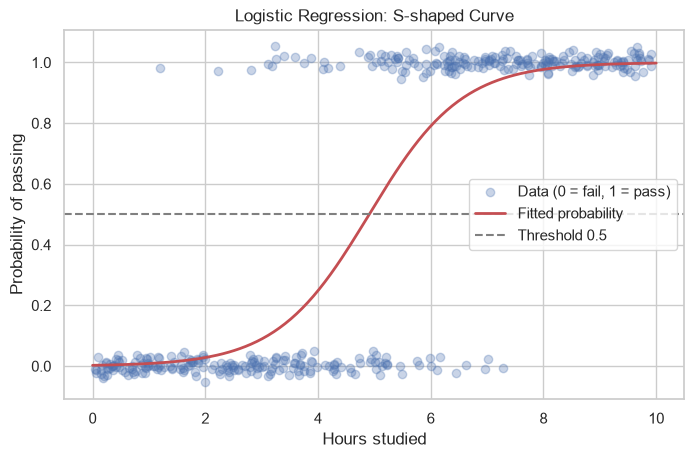

In [11]:
np.random.seed(42)
n = 400
hours = np.random.uniform(0, 10, n)
p_true = 1 / (1 + np.exp(-(1.2 * (hours - 5))))
passed = np.random.binomial(1, p_true)                 # Bernoulli outcomes

lr = LogisticRegression(C=1e6).fit(hours.reshape(-1, 1), passed)    # very weak regularization
b0, b1 = lr.intercept_[0], lr.coef_[0, 0]

print("Intercept:", round(b0, 3), "| Coefficient:", round(b1, 3), "(true: -6.0 and 1.2)")
print("Odds ratio per extra hour:", round(np.exp(b1), 2))
for h in [2, 5, 8]:
    print(f"P(pass | {h} hours) = {lr.predict_proba([[h]])[0, 1]:.3f}")

# Log loss: manual vs sklearn
p_hat = lr.predict_proba(hours.reshape(-1, 1))[:, 1]
manual_ll = -np.mean(passed * np.log(p_hat) + (1 - passed) * np.log(1 - p_hat))
print("\nLog loss (manual) :", round(manual_ll, 4))
print("Log loss (sklearn):", round(log_loss(passed, p_hat), 4))

xs = np.linspace(0, 10, 200)
plt.figure(figsize=(8, 4.8))
plt.scatter(hours, passed + np.random.normal(0, 0.02, n), alpha=0.3, label="Data (0 = fail, 1 = pass)")
plt.plot(xs, lr.predict_proba(xs.reshape(-1, 1))[:, 1], "r-", linewidth=2, label="Fitted probability")
plt.axhline(0.5, color="gray", linestyle="--", label="Threshold 0.5")
plt.xlabel("Hours studied"); plt.ylabel("Probability of passing")
plt.title("Logistic Regression: S-shaped Curve"); plt.legend(); plt.show()

**Explanation:** We generate pass / fail outcomes from a known S-curve, fit Logistic Regression and read the coefficient, odds ratio and predicted probabilities. Then we calculate the log loss formula ourselves and compare with sklearn.

**Interpretation:** The fitted coefficients are close to the true values (-6 and 1.2). The odds ratio of about 3.3 means that each extra hour multiplies the odds of passing by roughly 3. The probability rises smoothly from near 0 to near 1 in an **S-shape**, so predictions are always valid probabilities, unlike a straight line, which could go below 0 or above 1. The manual log loss matches sklearn, which shows that the training objective is simply the Bernoulli likelihood. The 0.5 threshold can be moved depending on the cost of Type I and Type II errors.

## 10. Naive Bayes

**Definition:** A classifier that applies **Bayes' Theorem** (Notebook 5) and **naively assumes that all features are independent given the class**. It picks the class with the highest posterior probability.

**Formula:**

$$P(C \mid x_1, \dots, x_n) \propto P(C) \prod_{i=1}^{n} P(x_i \mid C)$$

For numeric features (Gaussian Naive Bayes), each P(x | C) comes from a normal distribution with the class mean and variance:

$$P(x_i \mid C) = \frac{1}{\sqrt{2\pi\sigma_C^2}} e^{-\frac{(x_i - \mu_C)^2}{2\sigma_C^2}}$$

**Numerical Example (spam):** P(spam) = 0.4, P(ham) = 0.6. Word probabilities: P("offer" | spam) = 0.6, P("free" | spam) = 0.5, P("offer" | ham) = 0.05, P("free" | ham) = 0.1.
Spam score = 0.4 x 0.6 x 0.5 = 0.12
Ham score = 0.6 x 0.05 x 0.1 = 0.003
P(spam | "offer", "free") = 0.12 / (0.12 + 0.003) = **0.976**

**Why "naive"?** Real features are rarely independent ("offer" and "free" often come together), but the assumption makes the model simple, fast and often surprisingly good.

**Business Example:** Email spam filtering, sentiment classification of reviews, tagging support tickets.

**AI/ML Example:** A fast baseline for text classification (Multinomial NB), and for numeric data (Gaussian NB). It works with small training sets.

Manual P(spam | 'offer', 'free'): 0.9756

Gaussian NB test accuracy: 0.911
Class priors: [0.333 0.333 0.333]

Learned class means (rows = classes):
            sepal length (cm)  sepal width (cm)  petal length (cm)  \
setosa                   4.99              3.43               1.49   
versicolor               5.95              2.73               4.24   
virginica                6.68              3.01               5.63   

            petal width (cm)  
setosa                  0.24  
versicolor              1.31  
virginica               2.07  

Posterior probabilities for one flower: {np.str_('setosa'): np.float64(0.0), np.str_('versicolor'): np.float64(0.0), np.str_('virginica'): np.float64(1.0)}
Prediction: virginica | Actual: virginica


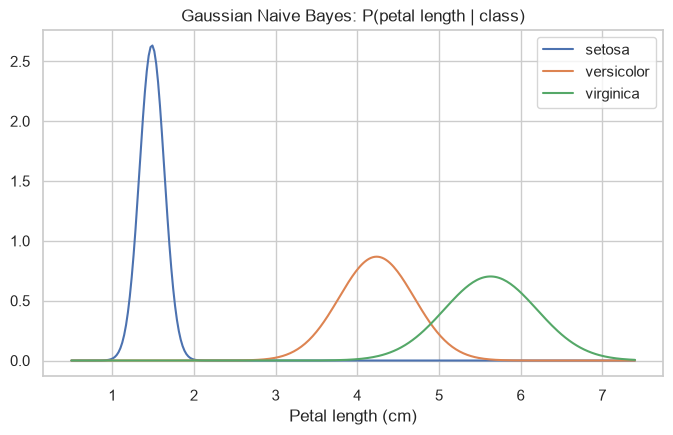

In [12]:
# Manual spam example
p_spam, p_ham = 0.4, 0.6
spam_score = p_spam * 0.6 * 0.5
ham_score = p_ham * 0.05 * 0.1
print("Manual P(spam | 'offer', 'free'):", round(spam_score / (spam_score + ham_score), 4))

# Gaussian Naive Bayes on the Iris dataset
iris = load_iris()
Xi_tr, Xi_te, yi_tr, yi_te = train_test_split(iris.data, iris.target, test_size=0.3,
                                              stratify=iris.target, random_state=42)
gnb = GaussianNB().fit(Xi_tr, yi_tr)
print("\nGaussian NB test accuracy:", round(gnb.score(Xi_te, yi_te), 3))
print("Class priors:", gnb.class_prior_.round(3))
print("\nLearned class means (rows = classes):")
print(pd.DataFrame(gnb.theta_, columns=iris.feature_names, index=iris.target_names).round(2))

sample = Xi_te[0].reshape(1, -1)
print("\nPosterior probabilities for one flower:", dict(zip(iris.target_names, gnb.predict_proba(sample)[0].round(4))))
print("Prediction:", iris.target_names[gnb.predict(sample)[0]], "| Actual:", iris.target_names[yi_te[0]])

# Visualize Gaussian likelihood of petal length per class
plt.figure(figsize=(8, 4.5))
feat = 2
xs = np.linspace(iris.data[:, feat].min() - 0.5, iris.data[:, feat].max() + 0.5, 300)
for c, name in enumerate(iris.target_names):
    plt.plot(xs, stats.norm.pdf(xs, gnb.theta_[c, feat], np.sqrt(gnb.var_[c, feat])), label=name)
plt.title("Gaussian Naive Bayes: P(petal length | class)"); plt.xlabel("Petal length (cm)")
plt.legend(); plt.show()

**Explanation:** The first part repeats the spam calculation by hand using Bayes' Theorem. Then `GaussianNB` learns, for each class, the prior, and the mean and variance of each feature. The final chart shows the bell curves it uses as likelihoods.

**Interpretation:** The manual posterior is about 0.976, so two spammy words are enough to flag the email. On Iris, Gaussian NB reaches a high accuracy (usually above 90%), although the features are correlated and the "naive" assumption is not really true. The predict_proba output shows the posterior of every class, and the class with the highest value wins. In the chart, the curves for setosa and the other two classes barely overlap for petal length, so that single feature almost separates the classes. **Naive Bayes is just Bayes' Theorem repeated for each feature.**

## 11. Clustering

**Definition:** Clustering groups similar observations **without labels** (unsupervised). K-Means is the most common method: it chooses k centers and assigns each point to the nearest one, then moves the centers to the mean of their points, and repeats.

**Formulas:**

Objective (inertia, within-cluster sum of squares):

$$J = \sum_{j=1}^{k}\sum_{x_i \in C_j} \lVert x_i - \mu_j \rVert^2$$

Silhouette score for a point (a = average distance to its own cluster, b = average distance to the nearest other cluster):

$$s = \frac{b - a}{\max(a, b)} \in [-1, 1]$$

**Statistics inside it:**
- The **mean** (centroid) represents each cluster, and the objective is the **sum of squared deviations** (variance within clusters).
- Distance depends on scale, so **standardize** first (Notebook section 5).
- To choose k: **elbow method** (where inertia stops dropping fast) and **silhouette score** (higher is better).

**Numerical Example:** Points 1, 2, 3 and 10, 11, 12 with k = 2: centroids 2 and 11. Inertia = (1 + 0 + 1) + (1 + 0 + 1) = **4**.

**Business Example:** Customer segmentation (high spenders, bargain hunters, occasional buyers) for targeted marketing.

**AI/ML Example:** Customer segmentation, grouping similar documents, image color compression, and creating cluster labels as features for supervised models.

C:\Users\haris\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\haris\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\haris\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\haris\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Window

Hand example centroids: [ 2. 11.] | inertia: 4.0
Silhouette scores: {2: np.float64(0.551), 3: np.float64(0.731), 4: np.float64(0.774), 5: np.float64(0.659), 6: np.float64(0.552), 7: np.float64(0.421), 8: np.float64(0.319)}
Best k by silhouette: 4


C:\Users\haris\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


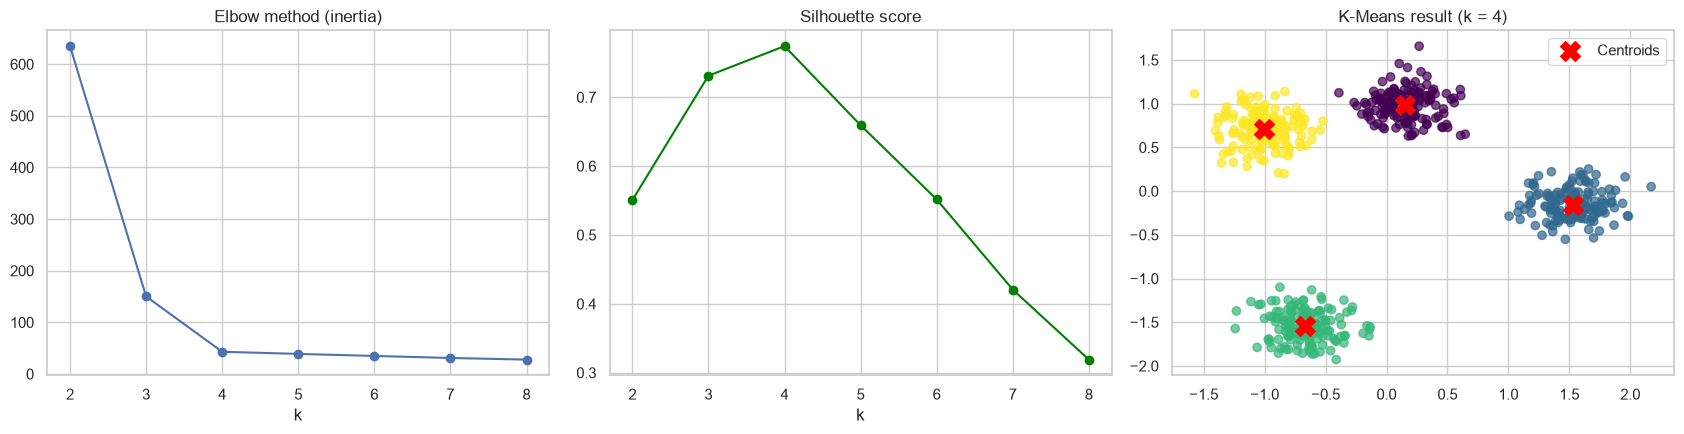

In [13]:
# Hand example
pts = np.array([1, 2, 3, 10, 11, 12]).reshape(-1, 1)
km_small = KMeans(n_clusters=2, n_init=10, random_state=42).fit(pts)
print("Hand example centroids:", np.sort(km_small.cluster_centers_.ravel()), "| inertia:", round(km_small.inertia_, 2))

# Blobs with 4 true clusters
Xb, _ = make_blobs(n_samples=600, centers=4, cluster_std=1.1, random_state=42)
Xb = StandardScaler().fit_transform(Xb)

ks = range(2, 9)
inertia, sil = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(Xb)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(Xb, km.labels_))

best_k = list(ks)[int(np.argmax(sil))]
print("Silhouette scores:", dict(zip(ks, np.round(sil, 3))))
print("Best k by silhouette:", best_k)

final = KMeans(n_clusters=best_k, n_init=10, random_state=42).fit(Xb)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
axes[0].plot(list(ks), inertia, "o-"); axes[0].set_title("Elbow method (inertia)"); axes[0].set_xlabel("k")
axes[1].plot(list(ks), sil, "o-", color="green"); axes[1].set_title("Silhouette score"); axes[1].set_xlabel("k")
axes[2].scatter(Xb[:, 0], Xb[:, 1], c=final.labels_, cmap="viridis", alpha=0.7)
axes[2].scatter(*final.cluster_centers_.T, color="red", marker="X", s=200, label="Centroids")
axes[2].set_title(f"K-Means result (k = {best_k})"); axes[2].legend()
plt.tight_layout(); plt.show()

**Explanation:** First K-Means is run on the six points from the markdown example, and gives the centroids 2 and 11 and the inertia 4. Then we create data with 4 true groups, standardize it, try k from 2 to 8, and record the inertia and the silhouette score for each k. The best k by silhouette is used for the final clustering.

**Interpretation:** Inertia always decreases when k grows, so we look for the **elbow** where the drop becomes slow. The silhouette score peaks near the true number of clusters (4), which means the groups are tight and well separated. The scatter plot shows the clusters and their centroids (the means). **Clustering has no "correct answer" to check, so we use statistics such as inertia and silhouette to judge it.**

## 12. Principal Component Analysis (PCA)

**Definition:** PCA reduces the number of features by creating **new, uncorrelated features (principal components)** that capture the **maximum variance** of the data. PC1 is the direction with the highest variance, PC2 is the next one perpendicular to it, and so on.

**Formulas:**

Covariance matrix: $\Sigma = \frac{1}{n-1} X^T X$ (X is centered)

Principal components are the **eigenvectors** of the covariance matrix, and the **eigenvalues** are the variances along them:

$$\Sigma v = \lambda v \qquad \text{Explained variance ratio}_i = \frac{\lambda_i}{\sum_j \lambda_j}$$

**Numerical Example:** Eigenvalues 3.0, 0.8, 0.2 give the explained variance 75%, 20% and 5%. The first two components keep **95%** of the information, so we can reduce 3 features to 2.

**Statistics inside it:** variance, covariance matrix, correlation (Notebooks 3 and 8). We **standardize first**, otherwise the feature with the largest scale dominates.

**Business Example:** Compressing 50 customer attributes into 5 components for faster segmentation, or combining correlated financial ratios into a few risk factors.

**AI/ML Example:** Removing multicollinearity (Notebook 12), speeding up training, **visualizing** high-dimensional data in 2D, and noise reduction. Drawback: components are mixtures of features, so they are harder to explain.

Explained variance ratio: [0.73  0.229 0.037 0.005]
Cumulative              : [0.73  0.958 0.995 1.   ]

Manual eigenvalues     : [2.938 0.92  0.148 0.021]
sklearn explained_var_ : [2.938 0.92  0.148 0.021]

Correlation matrix of PC1..PC4 (should be identity):
[[ 1. -0. -0. -0.]
 [-0.  1. -0.  0.]
 [-0. -0.  1. -0.]
 [-0.  0. -0.  1.]]


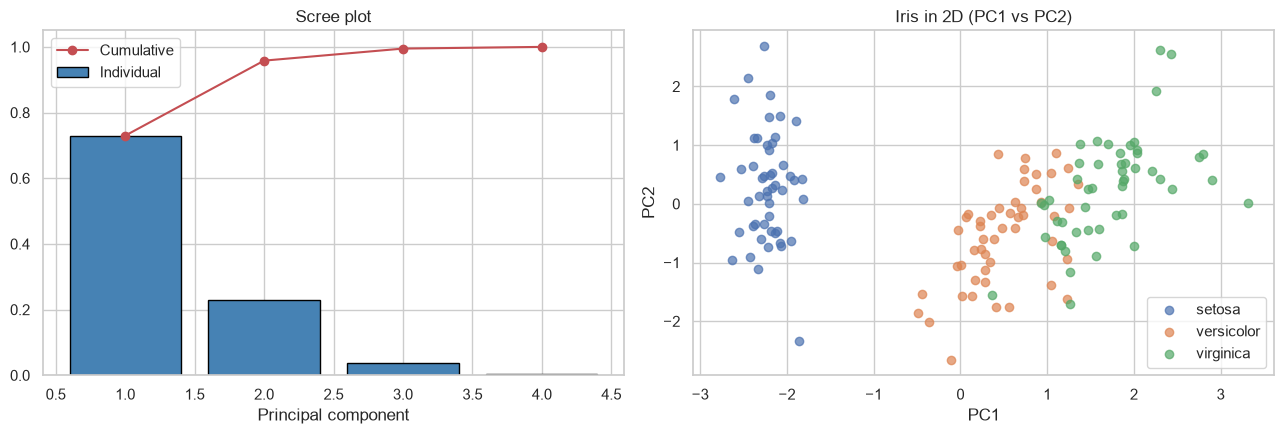

In [14]:
iris = load_iris()
Xs = StandardScaler().fit_transform(iris.data)

# sklearn PCA
pca = PCA().fit(Xs)
print("Explained variance ratio:", pca.explained_variance_ratio_.round(3))
print("Cumulative              :", np.cumsum(pca.explained_variance_ratio_).round(3))

# Manual: eigen decomposition of the covariance matrix
cov = np.cov(Xs.T)
eigvals, eigvecs = np.linalg.eigh(cov)
order = np.argsort(eigvals)[::-1]
eigvals = eigvals[order]
print("\nManual eigenvalues     :", eigvals.round(3))
print("sklearn explained_var_ :", pca.explained_variance_.round(3))

# Components are uncorrelated
Z = pca.transform(Xs)
print("\nCorrelation matrix of PC1..PC4 (should be identity):")
print(np.corrcoef(Z.T).round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(range(1, 5), pca.explained_variance_ratio_, color="steelblue", edgecolor="black", label="Individual")
axes[0].plot(range(1, 5), np.cumsum(pca.explained_variance_ratio_), "ro-", label="Cumulative")
axes[0].set_title("Scree plot"); axes[0].set_xlabel("Principal component"); axes[0].legend()

for c, name in enumerate(iris.target_names):
    axes[1].scatter(Z[iris.target == c, 0], Z[iris.target == c, 1], label=name, alpha=0.7)
axes[1].set_title("Iris in 2D (PC1 vs PC2)"); axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2"); axes[1].legend()
plt.tight_layout(); plt.show()

**Explanation:** We standardize the 4 Iris features and fit PCA. We then repeat the same math by hand: eigenvalues of the covariance matrix. The scree plot shows the variance of each component, and the scatter plot shows the data in the first two components.

**Interpretation:** PC1 alone keeps a bit over 70% of the variance, and PC1 + PC2 together keep about 96%, so 4 features can be reduced to 2 with little loss. Our manual eigenvalues match `explained_variance_`, so PCA is simply "eigen-analysis of the covariance matrix". The correlation matrix of the components is the identity, which means the components are **uncorrelated**. In the 2D plot, the three species are clearly separated even though the labels were not used in PCA.

## 13. Recommendation Systems

**Definition:** A recommendation system predicts what a user will like. **Collaborative filtering** finds users (or items) that behave similarly, and uses their ratings to predict the missing ratings.

**Statistics inside it:**
- **Similarity** between users is calculated with **Pearson correlation** (Notebook 8) or **cosine similarity**.
- Predictions are a **weighted average** (Notebook 2) of neighbours' ratings.
- **Mean-centering** removes the personal rating habit (some users always give 5 stars).

**Formulas:**

$$\text{cosine}(u, v) = \frac{u \cdot v}{\lVert u \rVert \, \lVert v \rVert}$$

$$\hat{r}_{u,i} = \bar{r}_u + \frac{\sum_{v} sim(u, v)\,(r_{v,i} - \bar{r}_v)}{\sum_{v} |sim(u, v)|}$$

**Numerical Example:** Users A = (5, 4) and B = (4, 5) on two items: cosine = (20 + 20) / (6.40 x 6.40) = **0.976** (very similar tastes).

**Business Example:** "Customers who bought this also bought..." on e-commerce, and "Because you watched..." on streaming.

**AI/ML Example:** User-based and item-based collaborative filtering, matrix factorization (which uses the same variance idea as PCA), and ranking models in production.

       Movie1  Movie2  Movie3  Movie4  Movie5
Asha      5.0       4     1.0     NaN     5.0
Bala      4.0       5     2.0     1.0     5.0
Charu     1.0       2     5.0     4.0     NaN
Dev       1.0       1     4.0     5.0     2.0
Esha      NaN       3     NaN     2.0     4.0

User similarity (Pearson):
        Asha  Bala  Charu   Dev  Esha
Asha   1.00  0.87  -1.00 -0.87  1.00
Bala   0.87  1.00  -0.80 -0.92  0.87
Charu -1.00 -0.80   1.00  0.89 -1.00
Dev   -0.87 -0.92   0.89  1.00 -0.72
Esha   1.00  0.87  -1.00 -0.72  1.00

Asha's average rating: 3.75
Predicted rating of Asha for Movie4: 2.1

Cosine similarity (A, B): 0.976


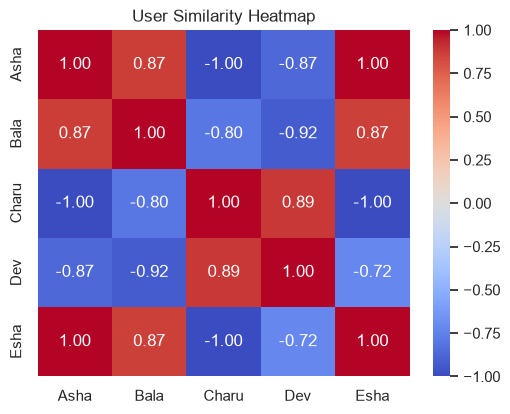

In [15]:
ratings = pd.DataFrame({
    "Movie1": [5, 4, 1, 1, np.nan],
    "Movie2": [4, 5, 2, 1, 3],
    "Movie3": [1, 2, 5, 4, np.nan],
    "Movie4": [np.nan, 1, 4, 5, 2],
    "Movie5": [5, 5, np.nan, 2, 4],
}, index=["Asha", "Bala", "Charu", "Dev", "Esha"])
print(ratings)

# User-user similarity (Pearson correlation on commonly rated movies)
sim = ratings.T.corr()
print("\nUser similarity (Pearson):\n", sim.round(2))

def predict(user, item):
    """Mean-centered weighted average of similar users' ratings."""
    user_mean = ratings.loc[user].mean()
    num, den = 0.0, 0.0
    for other in ratings.index:
        if other == user or np.isnan(ratings.loc[other, item]) or np.isnan(sim.loc[user, other]):
            continue
        s = sim.loc[user, other]
        if s <= 0:                               # use only positively similar users
            continue
        num += s * (ratings.loc[other, item] - ratings.loc[other].mean())
        den += abs(s)
    return user_mean if den == 0 else user_mean + num / den

pred = predict("Asha", "Movie4")
print("\nAsha's average rating:", round(ratings.loc["Asha"].mean(), 2))
print("Predicted rating of Asha for Movie4:", round(pred, 2))

# Cosine similarity example from the markdown
a, b = np.array([5, 4]), np.array([4, 5])
print("\nCosine similarity (A, B):", round(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)), 3))

plt.figure(figsize=(6, 4.5))
sns.heatmap(sim, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("User Similarity Heatmap"); plt.show()

**Explanation:** We build a small user x movie rating table with missing entries. `ratings.T.corr()` gives the Pearson correlation between every pair of users, using only the movies they both rated. To predict Asha's rating for Movie4, we take only users with a positive similarity, subtract each one's average rating (mean-centering), weight by similarity, and add back Asha's own average.

**Interpretation:** In the heatmap, Asha is strongly positive with Bala (they like Movie1, Movie2, Movie5) and negative with Charu and Dev (opposite tastes). Bala rated Movie4 low, so Asha's predicted rating for Movie4 comes out **low**, and we should not recommend it. The cosine example gives 0.976, meaning very similar tastes. **A recommender is mostly correlation and weighted averages.** The big limitation is the **cold-start problem**: a new user or movie has no ratings, so similarity cannot be computed.

## Summary: Statistics Behind Every ML Step

| ML topic | Key statistic | What to remember |
|---|---|---|
| Data cleaning | Duplicates, ranges, data types | Bad data gives bad models, and duplicates cause leakage |
| Missing values | Mean, median, mode | Median for skewed data, and imputation shrinks the variance |
| Outliers | IQR, Z-score | Detect first, then decide: error or real event? |
| Feature engineering | Skewness, ratios, correlation | Domain knowledge beats a complex algorithm |
| Scaling | Mean, std, median, IQR | Needed for distance and gradient based models, fit on train only |
| Normalization | Range, vector length, transformations | Scaling changes units, transformation changes shape |
| Model evaluation | Confusion matrix, CI, Type I / II errors | Accuracy can lie, so use precision, recall and cross-validation |
| Linear Regression | Covariance, variance, t-test | Slope = Cov / Var, and check residuals |
| Logistic Regression | Bernoulli, odds, likelihood | exp(coefficient) is the odds ratio |
| Naive Bayes | Bayes' Theorem, independence | Posterior = prior x likelihoods |
| Clustering | Mean, variance, distance | Choose k with elbow and silhouette, scale first |
| PCA | Covariance matrix, eigenvalues | Keeps maximum variance, and components are uncorrelated |
| Recommendation | Correlation, weighted mean | Similar users give predictions, and cold start is a problem |

## Advantages
- Statistical thinking makes the model **trustworthy**: we know when results are real, and not luck
- Helps to **diagnose** problems (skew, outliers, leakage, multicollinearity) before and after training
- Gives simple, explainable baseline models (Linear / Logistic Regression, Naive Bayes)
- Gives principled ways to compare models (cross-validation, confidence intervals, hypothesis tests)

## Limitations
- Many statistical methods assume normality, independence and linearity, and real data often breaks them
- Statistical significance does not mean practical value
- Simple statistical imputation and scaling can distort the data if applied blindly
- Statistical models can miss complex non-linear patterns that modern ML (trees, deep learning) can catch
- Doing preprocessing on the full dataset before splitting causes **data leakage**